## Setup and Imports

I start by loading all the libraries I’ll need for this analysis. This includes pandas for
data handling, SQLite to read from the database, NumPy for numeric work, and
Matplotlib/Seaborn for plotting.

I also adjust some display settings so that tables don’t get cut off when printed. This
helps make the data exploration smoother and clearer.


In [2]:
import sqlite3
import pandas as pd
import seaborn as sns
import numpy as np
import re as re
from matplotlib import pyplot as plt
pd.options.display.max_rows = 999
pd.options.display.max_columns = 90

## Connect to Database

Here I connect to the SQLite database (`bmarket.db`) and check the available tables.
Once I confirm that the main table is `bank_marketing`, I load it into a DataFrame.

From there, everything else is handled within pandas.


In [3]:
con = sqlite3.connect("bmarket.db")

In [4]:
cursor = con.cursor()

        # Query the sqlite_master table to get table names
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
        
        # Fetch all results
table_names = [row[0] for row in cursor.fetchall()]

In [5]:
print(table_names)

['bank_marketing']


In [6]:
query = "SELECT * FROM bank_marketing"  # Replace 'your_table_name' with the actual table name
df = pd.read_sql_query(query, con)
df.head(10)

,Client ID,Age,Occupation,Marital Status,Education Level,Credit Default,Housing Loan,Personal Loan,Contact Method,Campaign Calls,Previous Contact Days,Subscription Status
0,32885,57 years,technician,married,high.school,no,no,yes,Cell,1,999,no
1,3170,55 years,unknown,married,unknown,unknown,yes,no,telephone,2,999,no
2,32207,33 years,blue-collar,married,basic.9y,no,no,no,cellular,1,999,no
3,9404,36 years,admin.,married,high.school,no,no,no,Telephone,4,999,no
4,14021,27 years,housemaid,married,high.school,no,None,no,Cell,2,999,no
5,17202,58 years,retired,married,professional.course,no,None,yes,Cell,1,999,no
6,880,48 years,services,married,high.school,unknown,yes,no,Telephone,1,999,no
7,23758,150 years,admin.,divorced,university.degree,unknown,yes,None,Cell,7,999,no
8,10822,24 years,entrepreneur,married,university.degree,no,None,None,telephone,4,999,no
9,14356,36 years,technician,divorced,professional.course,no,yes,yes,Cell,4,999,no


## Initial Data Inspection

I check the shape, preview the first few rows, and use `df.info()` to get an overview of
the dataset. This gives me a sense of what columns exist, the data types, and where
missing values might appear.


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Client ID              41188 non-null  int64 
 1   Age                    41188 non-null  object
 2   Occupation             41188 non-null  object
 3   Marital Status         41188 non-null  object
 4   Education Level        41188 non-null  object
 5   Credit Default         41188 non-null  object
 6   Housing Loan           16399 non-null  object
 7   Personal Loan          37042 non-null  object
 8   Contact Method         41188 non-null  object
 9   Campaign Calls         41188 non-null  int64 
 10  Previous Contact Days  41188 non-null  int64 
 11  Subscription Status    41188 non-null  object
dtypes: int64(3), object(9)
memory usage: 3.8+ MB


## Checking Unique Values

Before cleaning, I loop through each column to print its unique values. This helps me
find issues like inconsistent category labels, placeholders such as “unknown”, and
unexpected values. These observations guide the cleaning steps.


In [8]:
for col in df.columns:
    print(f"\n🔹 {col} — {df[col].nunique()} unique values:")
    print(df[col].unique())


🔹 Client ID — 41188 unique values:
[32885  3170 32207 ... 38159   861 15796]

🔹 Age — 77 unique values:
['57 years' '55 years' '33 years' '36 years' '27 years' '58 years'
 '48 years' '150 years' '24 years' '34 years' '42 years' '43 years'
 '26 years' '37 years' '46 years' '59 years' '49 years' '30 years'
 '51 years' '45 years' '31 years' '41 years' '38 years' '47 years'
 '69 years' '50 years' '25 years' '39 years' '44 years' '52 years'
 '35 years' '77 years' '40 years' '56 years' '53 years' '60 years'
 '29 years' '28 years' '54 years' '32 years' '81 years' '63 years'
 '21 years' '22 years' '74 years' '80 years' '62 years' '68 years'
 '86 years' '23 years' '71 years' '67 years' '65 years' '20 years'
 '19 years' '66 years' '75 years' '18 years' '72 years' '70 years'
 '82 years' '85 years' '61 years' '88 years' '83 years' '78 years'
 '64 years' '17 years' '76 years' '73 years' '79 years' '89 years'
 '84 years' '91 years' '98 years' '92 years' '95 years']

🔹 Occupation — 12 unique values:

## Cleaning Text Columns

I standardise all text columns by converting them to lowercase, trimming extra spaces,
and renaming the columns to snake_case. This avoids treating similar values as separate
categories due only to formatting differences.


In [9]:
df = df.applymap(lambda x: x.strip().lower() if isinstance(x, str) else x)

C:\Users\tan98\AppData\Local\Temp\ipykernel_29340\1274793226.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.strip().lower() if isinstance(x, str) else x)


In [10]:
def to_snake(name):
    return re.sub(r'[\s\.-]+', '_', name.strip().lower())

df = df.rename(columns=lambda c: to_snake(c))
df

,client_id,age,occupation,marital_status,education_level,credit_default,housing_loan,personal_loan,contact_method,campaign_calls,previous_contact_days,subscription_status
0,32885,57 years,technician,married,high.school,no,no,yes,cell,1,999,no
1,3170,55 years,unknown,married,unknown,unknown,yes,no,telephone,2,999,no
2,32207,33 years,blue-collar,married,basic.9y,no,no,no,cellular,1,999,no
3,9404,36 years,admin.,married,high.school,no,no,no,telephone,4,999,no
4,14021,27 years,housemaid,married,high.school,no,None,no,cell,2,999,no
...,...,...,...,...,...,...,...,...,...,...,...,...
41183,6266,58 years,retired,married,professional.course,unknown,no,no,telephone,2,999,no
41184,11285,37 years,management,married,university.degree,no,no,no,telephone,1,999,no
41185,38159,35 years,admin.,married,high.school,no,None,no,cellular,1,4,yes
41186,861,40 years,management,married,university.degree,no,None,no,telephone,2,999,no


## Missing Value Overview

Next, I check how many missing values are present in each column. This helps me plan
which fields will need imputation and how important each missingness issue is.


In [11]:
df.isna().sum()

client_id                    0
age                          0
occupation                   0
marital_status               0
education_level              0
credit_default               0
housing_loan             24789
personal_loan             4146
contact_method               0
campaign_calls               0
previous_contact_days        0
subscription_status          0
dtype: int64

## Cleaning the Age Column

Some age values contain text like "years" or unusual characters. I strip these out and
convert everything to numeric. Any unrealistic ages are replaced with NaN so they can be
handled during imputation.


In [12]:
# Remove the word 'years' from the 'age' column and convert to numeric
if 'age' in df.columns:
    df['age'] = (
        df['age']
        .astype(str)
        .str.replace('years', '', case=False)
        .str.strip()
    )
    df['age'] = pd.to_numeric(df['age'], errors='coerce')

# Verify change
df['age'].value_counts(dropna=False)

age
150    4197
31     1747
32     1646
33     1643
36     1606
35     1584
34     1577
30     1536
37     1345
29     1310
38     1283
39     1281
41     1142
40     1027
42     1020
45      979
43      950
46      920
44      892
28      892
48      875
47      833
50      778
27      765
49      758
52      689
51      676
53      654
56      636
26      630
54      628
57      597
55      589
25      536
58      511
24      414
59      409
60      254
23      207
22      123
21       90
61       66
20       62
62       55
64       55
66       54
63       50
71       47
65       42
70       40
19       38
73       33
69       32
68       31
76       30
74       30
72       30
80       29
18       27
78       23
67       21
75       20
88       19
77       18
81       16
83       16
82       16
85       15
79       13
86        8
84        7
17        5
92        4
89        2
91        2
98        2
95        1
Name: count, dtype: int64

## Cleaning Occupation and Education Fields

Occupation and education_level contain formatting inconsistencies such as dots,
hyphens, and spacing differences. Here I standardise these categories so that similar
values are merged rather than treated separately.


In [13]:
df["occupation"] = df["occupation"].astype(str).str.replace(".", "", regex=False)
df['occupation'] = df['occupation'].astype(str).str.replace("-", "_", regex=False)
df["occupation"].value_counts(dropna=False)

occupation
admin            10422
blue_collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self_employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

In [14]:
df["education_level"] = df["education_level"].astype(str).str.replace(".", "_", regex=False)
df["education_level"].value_counts(dropna=False)

education_level
university_degree      12168
high_school             9515
basic_9y                6045
professional_course     5243
basic_4y                4176
basic_6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

## Cleaning Contact Method and Special Codes

I standardise contact_method values, fix inconsistent labels, and convert placeholder
values like "unknown" and numeric codes like 999 into proper NaN so they can be handled
consistently later.


In [15]:
# Standarize the value
if 'contact_method' in df.columns:
    df['contact_method'] = df['contact_method'].replace(['cell'], 'cellular')
    df['contact_method'] = df['contact_method'].replace(['Telephone'], 'telephone')

# Check if replacement worked
df['contact_method'].value_counts()

contact_method
cellular     26144
telephone    15044
Name: count, dtype: int64

In [16]:
df.loc[df['campaign_calls'] < 0, 'campaign_calls'] = 0
df['campaign_calls'].value_counts(dropna=False)

campaign_calls
1     15874
2      9446
3      4807
0      4153
4      2405
5      1451
6       893
7       566
8       365
9       253
10      206
11      156
12      107
13       84
14       58
17       51
15       47
16       46
18       30
20       27
19       24
21       22
24       15
22       14
23       11
27       11
29        9
26        8
30        7
25        7
31        7
28        6
33        4
32        3
34        3
35        3
42        2
40        2
43        2
56        1
39        1
37        1
Name: count, dtype: int64

In [17]:
df['subscription_status'].value_counts(dropna=False)

subscription_status
no     36548
yes     4640
Name: count, dtype: int64

In [18]:
df = df.replace("unknown", np.nan)
df = df.replace({None: np.nan})
df["previous_contact_days"] = df["previous_contact_days"].replace(999, np.nan)
df["age"] = df["age"].replace(150, np.nan)

## Unique Values After Cleaning

After cleaning, I recheck the unique values to confirm that categories look consistent
and that messy labels have been successfully merged or corrected.


In [19]:
for col in df.columns:
    print(f"\n🔹 {col} — {df[col].nunique()} unique values:")
    print(df[col].unique())


🔹 client_id — 41188 unique values:
[32885  3170 32207 ... 38159   861 15796]

🔹 age — 76 unique values:
[57. 55. 33. 36. 27. 58. 48. nan 24. 34. 42. 43. 26. 37. 46. 59. 49. 30.
 51. 45. 31. 41. 38. 47. 69. 50. 25. 39. 44. 52. 35. 77. 40. 56. 53. 60.
 29. 28. 54. 32. 81. 63. 21. 22. 74. 80. 62. 68. 86. 23. 71. 67. 65. 20.
 19. 66. 75. 18. 72. 70. 82. 85. 61. 88. 83. 78. 64. 17. 76. 73. 79. 89.
 84. 91. 98. 92. 95.]

🔹 occupation — 11 unique values:
['technician' nan 'blue_collar' 'admin' 'housemaid' 'retired' 'services'
 'entrepreneur' 'unemployed' 'management' 'self_employed' 'student']

🔹 marital_status — 3 unique values:
['married' 'divorced' 'single' nan]

🔹 education_level — 7 unique values:
['high_school' nan 'basic_9y' 'professional_course' 'university_degree'
 'basic_4y' 'basic_6y' 'illiterate']

🔹 credit_default — 2 unique values:
['no' nan 'yes']

🔹 housing_loan — 2 unique values:
['no' 'yes' nan]

🔹 personal_loan — 2 unique values:
['yes' 'no' nan]

🔹 contact_method — 2 uniq

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   client_id              41188 non-null  int64  
 1   age                    36991 non-null  float64
 2   occupation             40858 non-null  object 
 3   marital_status         41108 non-null  object 
 4   education_level        39457 non-null  object 
 5   credit_default         32591 non-null  object 
 6   housing_loan           16006 non-null  object 
 7   personal_loan          36165 non-null  object 
 8   contact_method         41188 non-null  object 
 9   campaign_calls         41188 non-null  int64  
 10  previous_contact_days  1515 non-null   float64
 11  subscription_status    41188 non-null  object 
dtypes: float64(2), int64(2), object(8)
memory usage: 3.8+ MB


In [21]:
df.isna().sum()

client_id                    0
age                       4197
occupation                 330
marital_status              80
education_level           1731
credit_default            8597
housing_loan             25182
personal_loan             5023
contact_method               0
campaign_calls               0
previous_contact_days    39673
subscription_status          0
dtype: int64

## Exploring Relationships Between Columns

With the basic cleaning done, I start exploring how major demographic fields relate to
each other. This helps me understand which variables are useful when imputing missing
values and when building predictive models.


### Age vs Occupation — Insight

The age ranges across occupations look very natural. Students are consistently the
youngest group, while retired clients appear in the highest age range. Jobs like
technician, services, and blue_collar mostly fall into the mid-age range.

These strong and realistic patterns help more than just age imputation — they also make
occupation a reliable variable when predicting or filling missing values in education and
marital status, since age tends to move together with both.

<Figure size 1400x600 with 0 Axes>

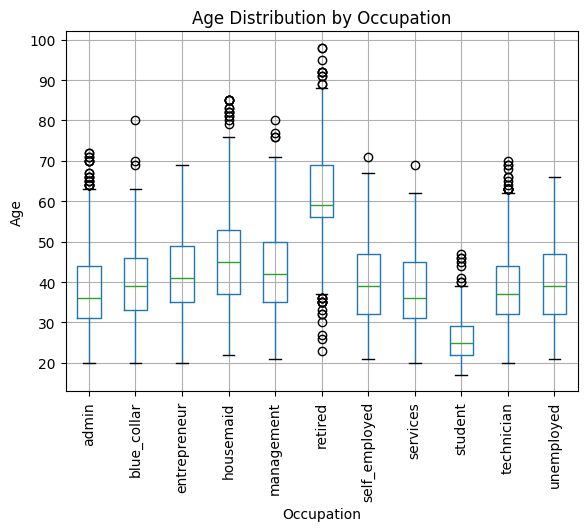

In [22]:
plt.figure(figsize=(14,6))
df.boxplot(column="age", by="occupation", rot=90)
plt.title("Age Distribution by Occupation")
plt.suptitle("")   # removes automatic title
plt.xlabel("Occupation")
plt.ylabel("Age")
plt.show()


### Age vs Marital Status — Insight

Single clients skew younger, married clients make up the mid-life range, and divorced clients appear more in older age groups. This matches normal life-stage
progressions.

Because age aligns closely with marital status, this relationship supports both age
imputation and any imputation involving marital_status. It also indirectly helps
occupation and education imputation since marital status often moves together with
career and study progression.

<Figure size 800x500 with 0 Axes>

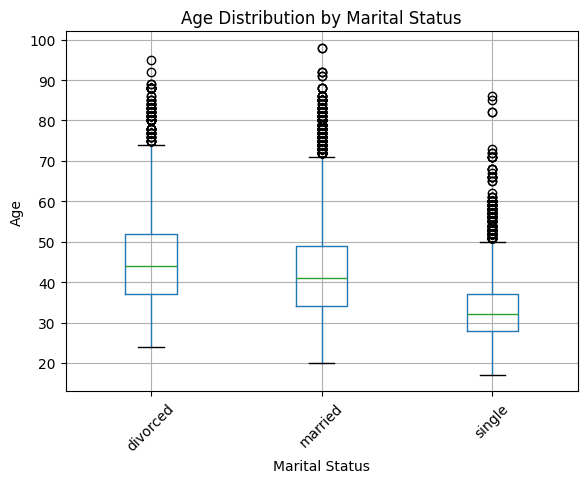

In [23]:
plt.figure(figsize=(8,5))
df.boxplot(column="age", by="marital_status", rot=45)
plt.title("Age Distribution by Marital Status")
plt.suptitle("")
plt.xlabel("Marital Status")
plt.ylabel("Age")
plt.show()


### Age vs Education Level — Insight

Higher education levels (university degrees, professional courses) are more common among
younger adults, while basic education groups appear more in older age ranges.

This pattern is extremely helpful not only for age imputation, but also for imputing
occupation and marital_status. Education level often reflects career stage and life
stage, so this relationship strengthens the reliability of multiple imputation steps.

<Figure size 1000x500 with 0 Axes>

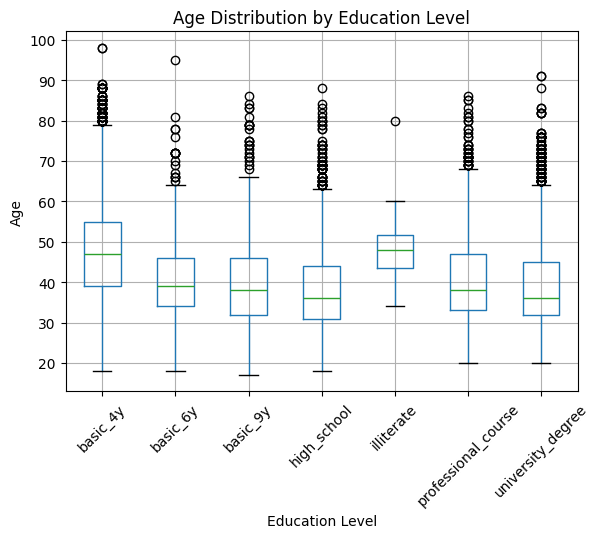

In [24]:
plt.figure(figsize=(10,5))
df.boxplot(column="age", by="education_level", rot=45)
plt.title("Age Distribution by Education Level")
plt.suptitle("")
plt.xlabel("Education Level")
plt.ylabel("Age")
plt.show()

### Education Level vs Occupation — Insight

Higher education groups are concentrated in office-based, administrative, or professional
jobs, while basic education groups appear more in manual, blue_collar, and service roles.

This is one of the strongest relationships in the dataset and helps guide occupation,
marital, and even education imputation. When two variables move so closely together,
missing values can be filled with high confidence using this structure.

In [25]:
pd.crosstab(
    df["education_level"],
    df["occupation"],
    normalize="index"
).round(3) * 100


occupation,admin,blue_collar,entrepreneur,housemaid,management,retired,self_employed,services,student,technician,unemployed
education_level,,,,,,,,,,,
basic_4y,1.9,56.2,3.3,11.5,2.4,14.5,2.3,3.2,0.6,1.4,2.7
basic_6y,6.7,62.8,3.1,3.4,3.7,3.3,1.1,10.0,0.6,3.8,1.5
basic_9y,8.3,60.2,3.5,1.6,2.8,2.4,3.7,6.5,1.6,6.4,3.1
high_school,35.1,9.3,2.5,1.8,3.1,2.9,1.2,28.3,3.8,9.2,2.7
illiterate,5.6,44.4,11.1,5.6,0.0,16.7,16.7,0.0,0.0,0.0,0.0
professional_course,6.9,8.7,2.6,1.1,1.7,4.6,3.2,4.2,0.8,63.5,2.7
university_degree,47.5,0.8,5.0,1.1,17.0,2.4,6.3,1.4,1.4,14.9,2.2


### Marital Status vs Occupation — Insight

Students are mostly single, most working occupations consist mainly of married clients,
and retired clients have a larger share of divorced individuals.

Since occupation and marital status follow consistent life-stage patterns, they help each
other during imputation. This relationship supports imputing missing occupation,
marital_status, and even education values because these demographics tend to shift
together.

In [26]:
pd.crosstab(
    df["marital_status"],
    df["occupation"],
    normalize="index"
).round(3) * 100

occupation,admin,blue_collar,entrepreneur,housemaid,management,retired,self_employed,services,student,technician,unemployed
marital_status,,,,,,,,,,,
divorced,27.8,15.8,3.9,3.5,7.2,7.6,2.9,11.6,0.2,16.8,2.7
married,21.3,27.1,4.3,3.1,8.5,5.2,3.7,9.3,0.2,14.9,2.6
single,33.7,15.9,1.8,1.0,4.4,0.8,3.3,9.9,7.2,19.9,2.2


### Education Level vs Marital Status — Insight

Basic education groups lean heavily toward being married, while higher education levels
have noticeably higher proportions of single individuals. University graduates, in
particular, show the highest single share.

This aligns well with age and life-stage behaviour, and it provides valuable structure
for imputing education_level and marital_status. Because marital and educational
attainment tend to be connected to age and career progression, this relationship supports
multiple imputation layers in your notebook.

In [27]:
pd.crosstab(
    df["education_level"],
    df["marital_status"],
    normalize="index"
).round(3) * 100


marital_status,divorced,married,single
education_level,,,
basic_4y,11.7,77.4,10.9
basic_6y,8.0,77.3,14.7
basic_9y,9.4,68.8,21.8
high_school,12.6,54.3,33.2
illiterate,11.1,83.3,5.6
professional_course,12.5,60.3,27.2
university_degree,11.0,52.7,36.3


## Multi-Stage Age Imputation

Instead of filling missing ages with a single median, I use a staged imputation approach
based on the strong demographic patterns observed earlier. Age is closely related to
occupation, marital status, and education level, so it makes sense to use these fields
when deciding on a realistic age for a client.

The function first tries the median age from the most detailed group:
occupation + marital_status + education_level.

If that group doesn’t have enough data, it falls back to a simpler group
using only occupation. And only if both options fail, it uses the overall median.

This ensures that imputed ages match natural patterns in the dataset and remain consistent
with the client’s likely life stage. Because age influences other demographic variables,
a careful approach here also improves the accuracy of later imputations.

In [28]:
def impute_age_special(df, edu_col="education_level", age_col="age", occ_col="occupation", ms_col="marital_status"):
    """
    Impute NULLs in age using staged medians:
      Stage A: median by (education_level, occupation, marital_status)
      Stage B: median by (occupation, marital_status)
      Stage C: median by (occupation)
      Stage D: global median

    Assumes:
      - `age` is already numeric
      - invalid ages like 150 already replaced with NaN
    Returns:
      df_out, report_dict
    """
    out = df.copy()

    # Ensure numeric age
    out[age_col] = pd.to_numeric(out[age_col], errors="coerce")

    # Normalize grouping keys (similar style to occupation imputation)
    for c in [occ_col, ms_col]:
        if c in out.columns:
            out[c] = (
                out[c]
                .astype(str)
                .str.strip()
                .str.lower()
                .replace({"": np.nan, "nan": np.nan})
            )

    before_missing = int(out[age_col].isna().sum())

    def gmedian(s: pd.Series):
        s = s.dropna()
        return float(s.median()) if not s.empty else np.nan

    report = {}

    # ---------- Stage A: (occupation, marital_status, education_level) ----------
    missing = out[age_col].isna()
    if missing.sum() > 0:
        medA = (
            out.groupby([edu_col, occ_col, ms_col])[age_col]
               .apply(gmedian)
               .rename("__med")
               .reset_index()
        )
        out = out.merge(medA, on=[edu_col, occ_col, ms_col], how="left")
        fillA = missing & out["__med"].notna()
        out.loc[fillA, age_col] = out.loc[fillA, "__med"]
        out = out.drop(columns="__med")
        report["filled_stage_A"] = int(fillA.sum())
    else:
        report["filled_stage_A"] = 0

    # ---------- Stage B: (occupation, marital_status) ----------
    missing = out[age_col].isna()
    if missing.sum() > 0:
        medB = (
            out.groupby([occ_col, ms_col])[age_col]
               .apply(gmedian)
               .rename("__med")
               .reset_index()
        )
        out = out.merge(medB, on=[occ_col, ms_col], how="left")
        fillB = missing & out["__med"].notna()
        out.loc[fillB, age_col] = out.loc[fillB, "__med"]
        out = out.drop(columns="__med")
        report["filled_stage_B"] = int(fillB.sum())
    else:
        report["filled_stage_B"] = 0

        # ---------- Stage C: (occupation) ----------
    missing = out[age_col].isna()
    if missing.sum() > 0:
        medC = (
            out.groupby([occ_col])[age_col]
               .apply(gmedian)
               .rename("__med")
               .reset_index()
        )
        out = out.merge(medC, on=[occ_col], how="left")
        fillC = missing & out["__med"].notna()
        out.loc[fillC, age_col] = out.loc[fillC, "__med"]
        out = out.drop(columns="__med")
        report["filled_stage_C"] = int(fillC.sum())
    else:
        report["filled_stage_C"] = 0

    # ---------- Stage D: global median ----------
    missing = out[age_col].isna()
    if missing.sum() > 0:
        global_med = gmedian(out[age_col])
        out.loc[missing, age_col] = global_med
        report["filled_stage_D"] = int(missing.sum())
    else:
        report["filled_stage_D"] = 0

    after_missing = int(out[age_col].isna().sum())
    report["age_missing_before"] = before_missing
    report["age_missing_after"] = after_missing

    # Optional: see what ages were assigned for originally-missing rows
    originally_missing = df[age_col].isna()
    assigned = out.loc[originally_missing, age_col].value_counts().head(10)
    report["top_assigned_ages"] = assigned.to_dict()

    # Use nullable integer for nice display (no .0)
    out[age_col] = out[age_col].round().astype("Int64")

    return out, report

In [29]:
df, age_report = impute_age_special(df)

print("=== Age Imputation Report ===")
for k, v in age_report.items():
    print(k, ":", v)


=== Age Imputation Report ===
filled_stage_A : 4007
filled_stage_B : 150
filled_stage_C : 9
filled_stage_D : 31
age_missing_before : 4197
age_missing_after : 0
top_assigned_ages : {38.0: 706, 32.0: 564, 39.0: 379, 37.0: 359, 42.0: 328, 31.0: 249, 44.0: 232, 41.0: 203, 40.0: 190, 36.0: 125}


In [30]:
df['age'].value_counts(dropna=False)

age
32    2213
31    1996
38    1992
33    1757
36    1732
37    1704
39    1660
34    1639
35    1610
30    1568
42    1372
41    1345
29    1318
40    1217
44    1154
43    1054
45    1021
46     948
48     933
28     908
47     846
49     792
50     791
27     765
52     703
51     677
53     654
54     643
56     640
26     630
57     614
55     589
58     545
25     544
59     481
24     443
60     276
23     212
22     125
21      90
20      66
61      66
66      56
64      55
62      55
73      54
63      50
71      47
65      42
70      40
19      38
69      32
68      31
72      31
74      30
76      30
80      29
18      27
78      23
67      21
75      20
88      19
77      18
81      16
82      16
83      16
85      15
79      13
86       8
84       7
17       5
92       4
89       2
91       2
98       2
95       1
Name: count, dtype: Int64

## Creating Age Groups

After imputing the numerical age, I convert it into broader age groups such as 17–25,
26–35, and 36–50. These age bands help simplify later comparisons between demographic
features.

These age groups are also used in the occupation, marital status, and education imputation
functions because age often reflects life stage, career stage, and education attainment.
Grouping age therefore strengthens the structure behind the later imputations.

In [31]:
df["age"] = pd.to_numeric(df["age"], errors="coerce")

df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 25, 35, 45, 55, 65, float("inf")],
    labels=["<25", "25-34", "35-44", "45-54", "55-64", "65+"],
    right=False
)


## Multi-Stage Occupation Imputation

Missing occupation values are filled using a staged mode-based method. Since occupation is
strongly connected to education level, marital status, and age group, the function uses
these combinations to find the most likely job category for each client.

It starts with the most detailed grouping:
education_level + marital_status + age_group.

If that group doesn’t have enough examples, it steps down to simpler groupings and only
uses the overall mode if nothing else works.

This approach keeps imputed occupations realistic because it follows the natural patterns
seen in the data. It also helps improve later imputations since occupation is a key
predictor for both marital status and education.

In [32]:
def impute_occupation_with_stage(
    df,
    occ_col="occupation",
    edu_col="education_level",
    agegrp_col="age_group"
):
    """
    Staged occupation imputation using:
      Stage A: (education_level + age_group)
      Stage B: (education_level)
      Stage C: global mode

    Adds a column 'occupation_impute_stage' with values:
      'A', 'B', 'C' for imputed rows
      None / NaN for rows that were not imputed.
    """

    out = df.copy()

    # track which rows were originally missing
    orig_missing = out[occ_col].isna()

    # clean text columns
    for c in [occ_col, edu_col, agegrp_col]:
        if c in out.columns:
            out[c] = (
                out[c]
                .astype(str)
                .str.strip()
                .str.lower()
                .replace({"": np.nan, "nan": np.nan})
            )

    before_missing = int(out[occ_col].isna().sum())
    out["occupation_impute_stage"] = np.nan  # mark stages here

    def gmode(s: pd.Series):
        s = s.dropna()
        return s.mode().iloc[0] if not s.empty else np.nan

    report = {}

    # ---------- Stage A: edu + age_group ----------
    missing = out[occ_col].isna()
    if missing.sum() > 0:
        modA = (
            out.groupby([edu_col, agegrp_col])[occ_col]
               .apply(gmode)
               .rename("__mod")
               .reset_index()
        )
        out = out.merge(modA, on=[edu_col, agegrp_col], how="left")
        fillA = missing & out["__mod"].notna()
        out.loc[fillA, occ_col] = out.loc[fillA, "__mod"]
        # label stage for rows that were originally missing
        out.loc[fillA & orig_missing, "occupation_impute_stage"] = "A"
        out = out.drop(columns="__mod")
        report["filled_stage_A"] = int(fillA.sum())
    else:
        report["filled_stage_A"] = 0

    # ---------- Stage B: edu only ----------
    missing = out[occ_col].isna()
    if missing.sum() > 0:
        modB = (
            out.groupby([edu_col])[occ_col]
               .apply(gmode)
               .rename("__mod")
               .reset_index()
        )
        out = out.merge(modB, on=[edu_col], how="left")
        fillB = missing & out["__mod"].notna()
        out.loc[fillB, occ_col] = out.loc[fillB, "__mod"]
        out.loc[fillB & orig_missing, "occupation_impute_stage"] = "B"
        out = out.drop(columns="__mod")
        report["filled_stage_B"] = int(fillB.sum())
    else:
        report["filled_stage_B"] = 0

    # ---------- Stage C: global mode ----------
    missing = out[occ_col].isna()
    if missing.sum() > 0:
        global_mod = gmode(out[occ_col])
        out.loc[missing, occ_col] = global_mod
        out.loc[missing & orig_missing, "occupation_impute_stage"] = "C"
        report["filled_stage_C"] = int(missing.sum())
    else:
        report["filled_stage_C"] = 0

    after_missing = int(out[occ_col].isna().sum())
    report["occupation_missing_before"] = before_missing
    report["occupation_missing_after"] = after_missing

    return out, report, orig_missing


In [33]:
# run imputation
df, occ_report, orig_missing_mask = impute_occupation_with_stage(df)

print("=== Occupation Imputation Report ===")
for k, v in occ_report.items():
    print(k, ":", v)


=== Occupation Imputation Report ===
filled_stage_A : 199
filled_stage_B : 0
filled_stage_C : 131
occupation_missing_before : 330
occupation_missing_after : 0


C:\Users\tan98\AppData\Local\Temp\ipykernel_29340\990829146.py:56: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'A' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  out.loc[fillA & orig_missing, "occupation_impute_stage"] = "A"


In [34]:
assigned_rows = df.loc[orig_missing_mask, 
    ["age", "age_group", "education_level", "occupation", "occupation_impute_stage"]
]

print(assigned_rows.head(20))  # see first 20


      age age_group      education_level   occupation occupation_impute_stage
1      55     55-64                  NaN        admin                       C
22     26     25-34          high_school        admin                       A
29     38     35-44          high_school        admin                       A
334    34     25-34    university_degree        admin                       A
535    59     55-64                  NaN        admin                       C
746    52     45-54  professional_course   technician                       A
1001   35     35-44             basic_9y  blue_collar                       A
1175   38     35-44                  NaN        admin                       C
1364   36     35-44                  NaN        admin                       C
1556   38     35-44                  NaN        admin                       C
1591   24       <25    university_degree        admin                       A
1634   47     45-54                  NaN        admin           

## Multi-Stage Marital Status Imputation

Marital status is strongly tied to age, occupation, and education level. Younger clients
tend to be single, mid-career adults are usually married, and older clients show more
divorced or widowed entries.

The imputation function uses these patterns by starting with detailed groupings based on:
occupation + education_level + age_group.

If the detailed group does not provide a clear mode, it relaxes the grouping gradually,
eventually using the overall mode as a last resort.

This staged logic ensures that imputed marital statuses match typical life-stage
behaviour and stay in line with the rest of the client’s demographic profile.

In [35]:
def impute_marital_with_stage(
    df,
    ms_col="marital_status",
    edu_col="education_level",
    agegrp_col="age_group",
    occ_col="occupation"
):
    """
    Staged marital_status imputation using:
      Stage A: (education_level, age_group, occupation)
      Stage B: (education_level, age_group)
      Stage C: (age_group)
      Stage D: global mode

    Adds a new column: marital_impute_stage ('A','B','C','D')
    """
    out = df.copy()

    # Track original missing values
    orig_missing = out[ms_col].isna()

    # Clean text columns
    for c in [ms_col, edu_col, agegrp_col, occ_col]:
        if c in out.columns:
            out[c] = (
                out[c]
                .astype(str)
                .str.strip()
                .str.lower()
                .replace({"": np.nan, "nan": np.nan})
            )

    before_missing = int(out[ms_col].isna().sum())
    out["marital_impute_stage"] = np.nan

    def gmode(s: pd.Series):
        s = s.dropna()
        return s.mode().iloc[0] if not s.empty else np.nan

    report = {}

    # ---------- Stage A: (education_level, age_group, occupation) ----------
    missing = out[ms_col].isna()
    if missing.sum() > 0:
        modA = (
            out.groupby([edu_col, agegrp_col, occ_col])[ms_col]
               .apply(gmode)
               .rename("__mod")
               .reset_index()
        )
        out = out.merge(modA, on=[edu_col, agegrp_col, occ_col], how="left")
        fillA = missing & out["__mod"].notna()
        out.loc[fillA, ms_col] = out.loc[fillA, "__mod"]
        out.loc[fillA & orig_missing, "marital_impute_stage"] = "A"
        out = out.drop(columns="__mod")
        report["filled_stage_A"] = int(fillA.sum())
    else:
        report["filled_stage_A"] = 0

    # ---------- Stage B: (education_level, age_group) ----------
    missing = out[ms_col].isna()
    if missing.sum() > 0:
        modB = (
            out.groupby([edu_col, agegrp_col])[ms_col]
               .apply(gmode)
               .rename("__mod")
               .reset_index()
        )
        out = out.merge(modB, on=[edu_col, agegrp_col], how="left")
        fillB = missing & out["__mod"].notna()
        out.loc[fillB, ms_col] = out.loc[fillB, "__mod"]
        out.loc[fillB & orig_missing, "marital_impute_stage"] = "B"
        out = out.drop(columns="__mod")
        report["filled_stage_B"] = int(fillB.sum())
    else:
        report["filled_stage_B"] = 0

    # ---------- Stage C: (age_group only) ----------
    missing = out[ms_col].isna()
    if missing.sum() > 0:
        modC = (
            out.groupby([agegrp_col])[ms_col]
               .apply(gmode)
               .rename("__mod")
               .reset_index()
        )
        out = out.merge(modC, on=[agegrp_col], how="left")
        fillC = missing & out["__mod"].notna()
        out.loc[fillC, ms_col] = out.loc[fillC, "__mod"]
        out.loc[fillC & orig_missing, "marital_impute_stage"] = "C"
        out = out.drop(columns="__mod")
        report["filled_stage_C"] = int(fillC.sum())
    else:
        report["filled_stage_C"] = 0

    # ---------- Stage D: global mode ----------
    missing = out[ms_col].isna()
    if missing.sum() > 0:
        global_mod = gmode(out[ms_col])
        out.loc[missing, ms_col] = global_mod
        out.loc[missing & orig_missing, "marital_impute_stage"] = "D"
        report["filled_stage_D"] = int(missing.sum())
    else:
        report["filled_stage_D"] = 0

    after_missing = int(out[ms_col].isna().sum())
    report["marital_missing_before"] = before_missing
    report["marital_missing_after"] = after_missing

    return out, report, orig_missing


In [36]:
df, ms_report, ms_orig_missing = impute_marital_with_stage(df)

print("=== Marital Status Imputation Report ===")
for k, v in ms_report.items():
    print(k, ":", v)

=== Marital Status Imputation Report ===
filled_stage_A : 71
filled_stage_B : 0
filled_stage_C : 9
filled_stage_D : 0
marital_missing_before : 80
marital_missing_after : 0


C:\Users\tan98\AppData\Local\Temp\ipykernel_29340\2668240902.py:54: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'A' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  out.loc[fillA & orig_missing, "marital_impute_stage"] = "A"


In [37]:
assigned_ms = df.loc[ms_orig_missing, 
    ["age", "age_group", "education_level", "marital_status", "marital_impute_stage"]
]

print(assigned_ms.head(20))

      age age_group      education_level marital_status marital_impute_stage
503    37     35-44    university_degree        married                    A
913    36     35-44    university_degree        married                    A
1051   58     55-64    university_degree        married                    A
1112   29     25-34          high_school         single                    A
2424   27     25-34          high_school         single                    A
3424   25     25-34    university_degree         single                    A
3508   30     25-34             basic_9y         single                    A
4922   37     35-44    university_degree        married                    A
5008   66       65+             basic_9y        married                    A
5076   31     25-34  professional_course        married                    A
5105   45     45-54                  NaN        married                    C
5532   35     35-44             basic_9y        married                    A

## Multi-Stage Education Level Imputation

Education level also follows strong demographic structures. Higher education tends to be
associated with younger working adults and specific occupations like management or
professional roles. Basic education is more common in older clients and in jobs such as
services or blue_collar.

The imputation function uses these reliable patterns by checking combinations of:
occupation + marital_status + age_group.

If those do not give a clear answer, it moves to simpler combinations and eventually to
the overall mode.

This keeps imputed education levels consistent with real demographic behaviour and
maintains alignment with occupation and marital status, both of which closely relate to
education.

In [38]:
def impute_education_with_stage(
    df,
    edu_col="education_level",
    occ_col="occupation",
    agegrp_col="age_group",
    ms_col="marital_status"
):
    """
    Impute education_level using 5 stages:
      A: (occupation, age_group, marital_status)
      B: (occupation, age_group)
      C: (occupation)
      D: (age_group)
      E: global mode
    """

    out = df.copy()
    orig_missing = out[edu_col].isna()

    # clean text columns
    for c in [edu_col, occ_col, agegrp_col, ms_col]:
        out[c] = (
            out[c]
            .astype(str)
            .str.lower()
            .str.strip()
            .replace({"": np.nan, "nan": np.nan})
        )

    out["education_impute_stage"] = np.nan

    def gmode(s):
        s = s.dropna()
        return s.mode().iloc[0] if not s.empty else np.nan

    report = {}
    before_missing = int(out[edu_col].isna().sum())

    # ---------- Stage A: (occupation, age_group, marital_status) ----------
    missing = out[edu_col].isna()
    if missing.sum() > 0:
        modA = (
            out.groupby([occ_col, agegrp_col, ms_col])[edu_col]
               .apply(gmode).rename("__mod").reset_index()
        )
        out = out.merge(modA, on=[occ_col, agegrp_col, ms_col], how="left")
        fillA = missing & out["__mod"].notna()
        out.loc[fillA, edu_col] = out.loc[fillA, "__mod"]
        out.loc[fillA & orig_missing, "education_impute_stage"] = "A"
        out.drop(columns="__mod", inplace=True)
        report["stage_A"] = int(fillA.sum())
    else:
        report["stage_A"] = 0

    # ---------- Stage B: (occupation, age_group) ----------
    missing = out[edu_col].isna()
    if missing.sum() > 0:
        modB = (
            out.groupby([occ_col, agegrp_col])[edu_col]
               .apply(gmode).rename("__mod").reset_index()
        )
        out = out.merge(modB, on=[occ_col, agegrp_col], how="left")
        fillB = missing & out["__mod"].notna()
        out.loc[fillB, edu_col] = out.loc[fillB, "__mod"]
        out.loc[fillB & orig_missing, "education_impute_stage"] = "B"
        out.drop(columns="__mod", inplace=True)
        report["stage_B"] = int(fillB.sum())
    else:
        report["stage_B"] = 0

    # ---------- Stage C: (occupation only) ----------
    missing = out[edu_col].isna()
    if missing.sum() > 0:
        modC = (
            out.groupby([occ_col])[edu_col]
               .apply(gmode).rename("__mod").reset_index()
        )
        out = out.merge(modC, on=[occ_col], how="left")
        fillC = missing & out["__mod"].notna()
        out.loc[fillC, edu_col] = out.loc[fillC, "__mod"]
        out.loc[fillC & orig_missing, "education_impute_stage"] = "C"
        out.drop(columns="__mod", inplace=True)
        report["stage_C"] = int(fillC.sum())
    else:
        report["stage_C"] = 0

    # ---------- Stage D: (age_group only) ----------
    missing = out[edu_col].isna()
    if missing.sum() > 0:
        modD = (
            out.groupby([agegrp_col])[edu_col]
               .apply(gmode).rename("__mod").reset_index()
        )
        out = out.merge(modD, on=[agegrp_col], how="left")
        fillD = missing & out["__mod"].notna()
        out.loc[fillD, edu_col] = out.loc[fillD, "__mod"]
        out.loc[fillD & orig_missing, "education_impute_stage"] = "D"
        out.drop(columns="__mod", inplace=True)
        report["stage_D"] = int(fillD.sum())
    else:
        report["stage_D"] = 0

    # ---------- Stage E: global mode ----------
    missing = out[edu_col].isna()
    if missing.sum() > 0:
        global_mod = gmode(out[edu_col])
        out.loc[missing, edu_col] = global_mod
        out.loc[missing & orig_missing, "education_impute_stage"] = "E"
        report["stage_E"] = int(missing.sum())
    else:
        report["stage_E"] = 0

    report["before_missing"] = before_missing
    report["after_missing"] = int(out[edu_col].isna().sum())

    return out, report, orig_missing


In [39]:
df, edu_report2, edu_missing2 = impute_education_with_stage(df)
edu_report2


C:\Users\tan98\AppData\Local\Temp\ipykernel_29340\2026168518.py:49: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'A' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  out.loc[fillA & orig_missing, "education_impute_stage"] = "A"


{'stage_A': 1726,
 'stage_B': 0,
 'stage_C': 5,
 'stage_D': 0,
 'stage_E': 0,
 'before_missing': 1731,
 'after_missing': 0}

In [40]:
df.loc[
    edu_missing2,
    ["age", "age_group", "occupation", "marital_status",
     "education_level", "education_impute_stage"]
]


,age,age_group,occupation,marital_status,education_level,education_impute_stage
1,55,55-64,admin,married,university_degree,A
41,38,35-44,blue_collar,married,basic_9y,A
75,30,25-34,blue_collar,single,basic_9y,A
111,38,35-44,admin,married,university_degree,A
122,54,45-54,blue_collar,married,basic_4y,A
...,...,...,...,...,...,...
41137,47,45-54,services,married,high_school,A
41153,34,25-34,blue_collar,married,basic_9y,A
41175,50,45-54,services,married,high_school,A
41177,58,55-64,management,married,university_degree,A


## Credit Default Imputation

For credit_default, missing values are treated as "no". It is more reasonable to assume
that no default occurred unless explicitly stated, especially since default events are
rare and typically recorded clearly. This avoids incorrectly marking clients as risky when
there is no evidence.

In [41]:
df["credit_default"] = df["credit_default"].fillna("no")

In [42]:
df["credit_default"].value_counts(dropna=False)

credit_default
no     41185
yes        3
Name: count, dtype: int64

## Housing Loan Imputation

Missing values in housing_loan are assigned the label "unknown". Rather than assuming a
yes or no for a loan that is not recorded, keeping "unknown" as a category preserves
uncertainty and avoids introducing incorrect assumptions. The model can later decide
whether "unknown" itself carries a useful signal.

In [43]:
df["housing_loan"] = df["housing_loan"].fillna("unknown")

In [44]:
df["housing_loan"].value_counts(dropna=False)

housing_loan
unknown    25182
yes         8595
no          7411
Name: count, dtype: int64

## Personal Loan Imputation

The same logic applies to personal_loan. Missing values become "unknown" so I don’t make
any incorrect assumptions.


In [45]:
df["personal_loan"] = df["personal_loan"].fillna("unknown")

In [46]:
df["personal_loan"].value_counts(dropna=False)

personal_loan
no         30532
yes         5633
unknown     5023
Name: count, dtype: int64

## Univariate Analysis

I explore each variable individually — age distribution, occupation counts, marital
status proportions, education levels, and loan categories. This builds a solid
understanding of the data before comparing these features directly to the target.

### Univariate Analysis — Insight

The univariate charts help me understand the basic shape of the dataset before comparing
anything to the target.

The age histogram shows a smooth and realistic spread, with most clients falling between
30 and 60 years old. There are no sharp spikes or unusual gaps, which suggests that the
age cleaning and imputation steps worked properly. The distribution looks natural and
balanced enough for modelling.

The countplots for occupation, marital status, and education level also look consistent.
Some categories, like blue_collar and management, appear more frequently, which makes
sense in a general working population. The marital status distribution is typical as well,
with "married" being the largest group. Education levels follow expected patterns, with
basic and high_school categories appearing more often.

The loan and default distributions also look realistic. Most clients do not have personal
or housing loans, and the majority have no credit default — both expected behaviours for a
general banking dataset.

Overall, nothing looks artificially skewed or suspicious. This gives confidence that the
dataset is clean and that the imputed values blend naturally with the original data.


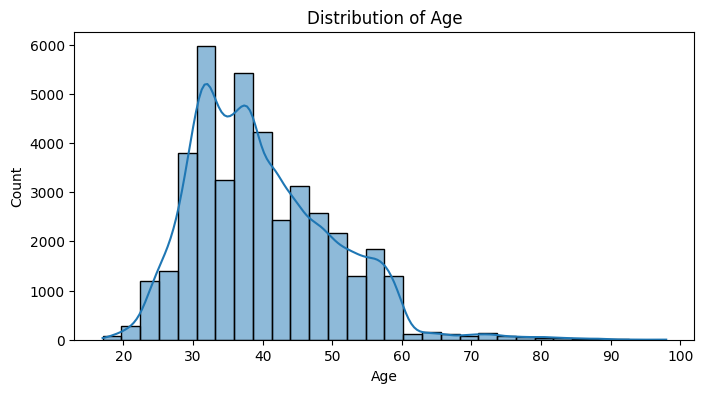

In [47]:
plt.figure(figsize=(8,4))
sns.histplot(df["age"], bins=30, kde=True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

In [48]:
def countplot_with_labels(column):
    plt.figure(figsize=(10,4))
    ax = sns.countplot(
        data=df,
        x=column,
        order=df[column].value_counts().index
    )
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.xticks(rotation=45)

    # Add labels on top of bars
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(
            f'{height}',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom'
        )

    plt.show()


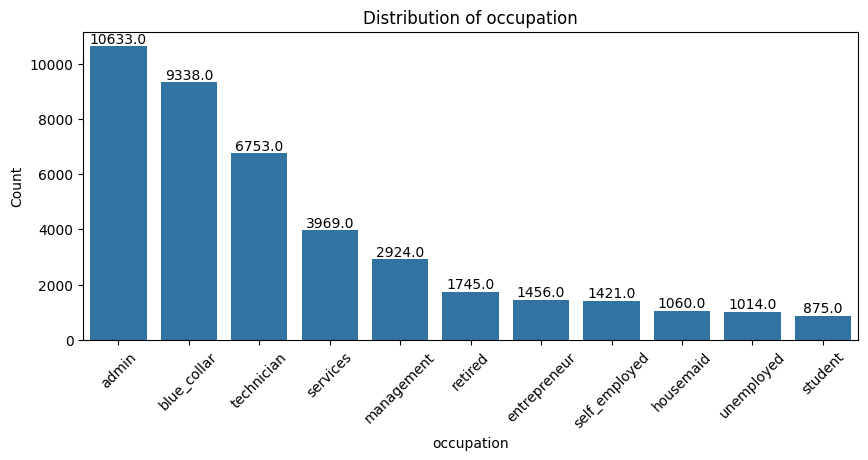

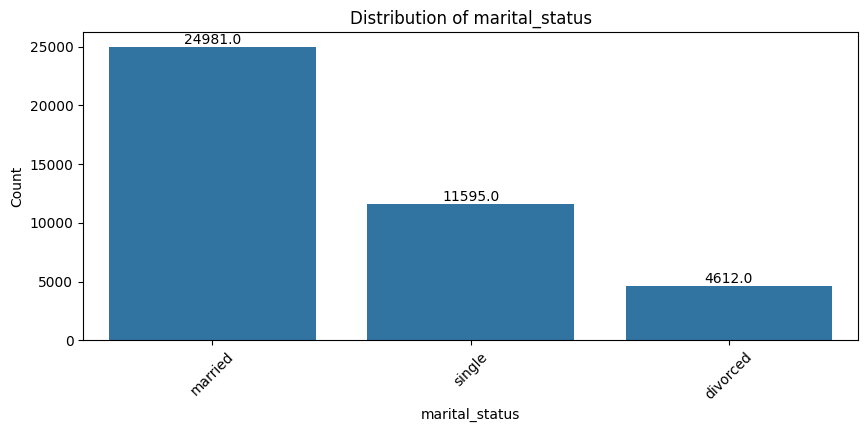

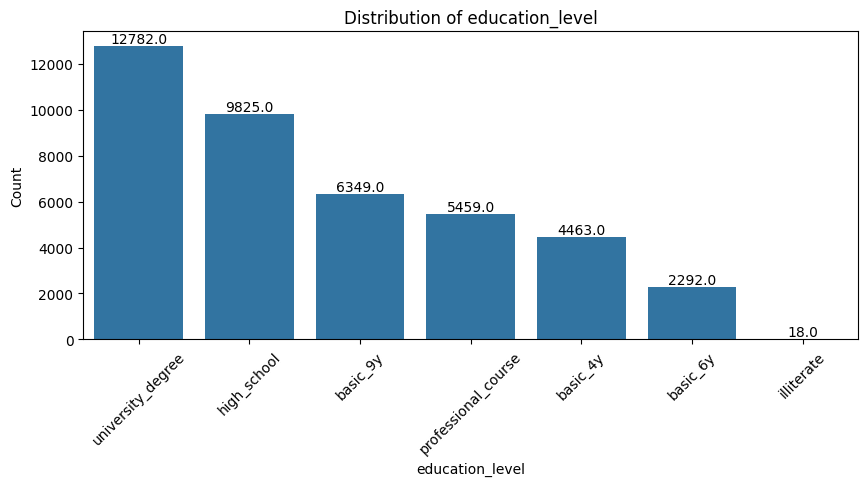

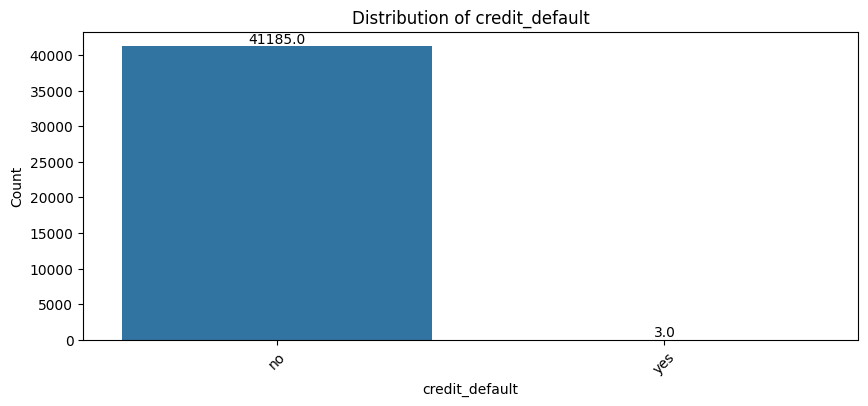

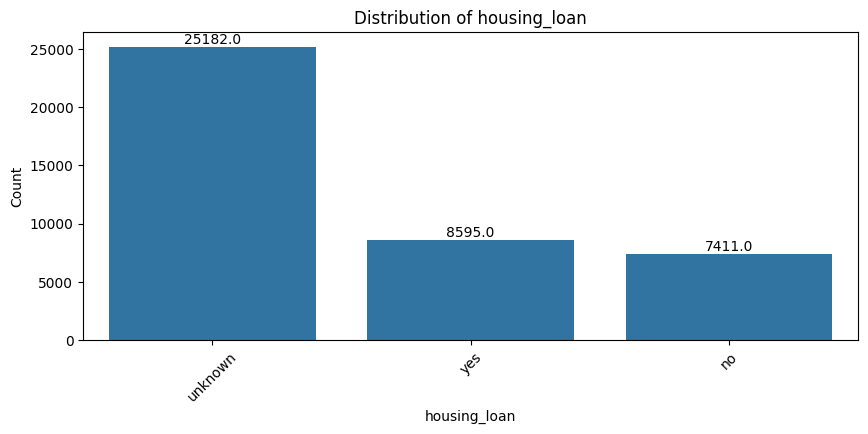

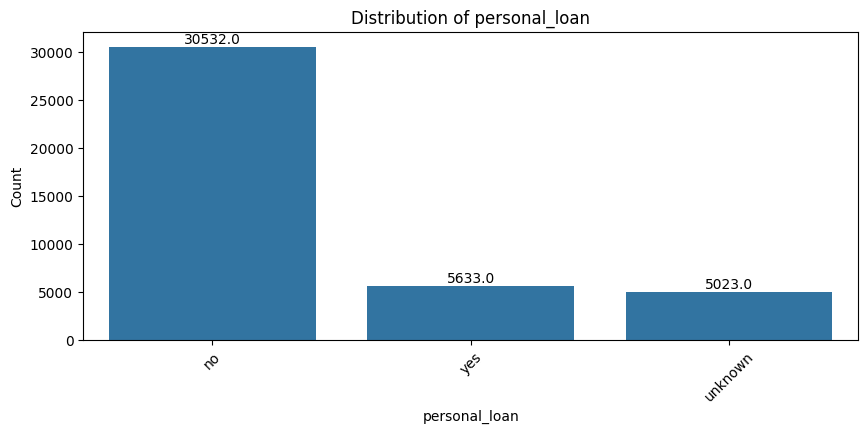

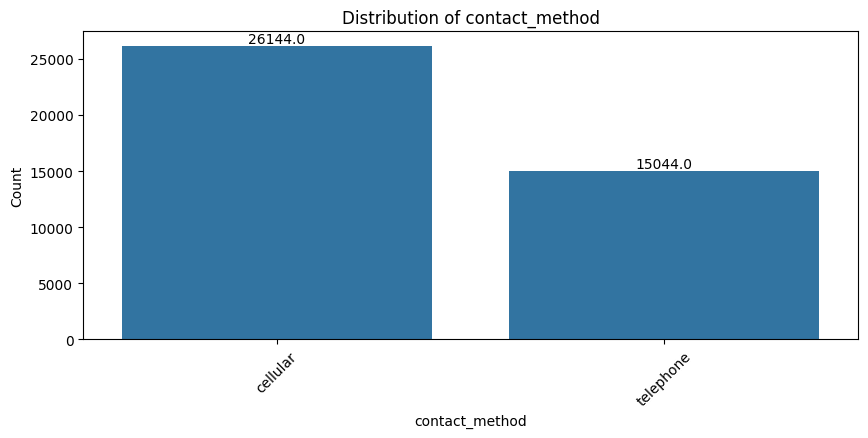

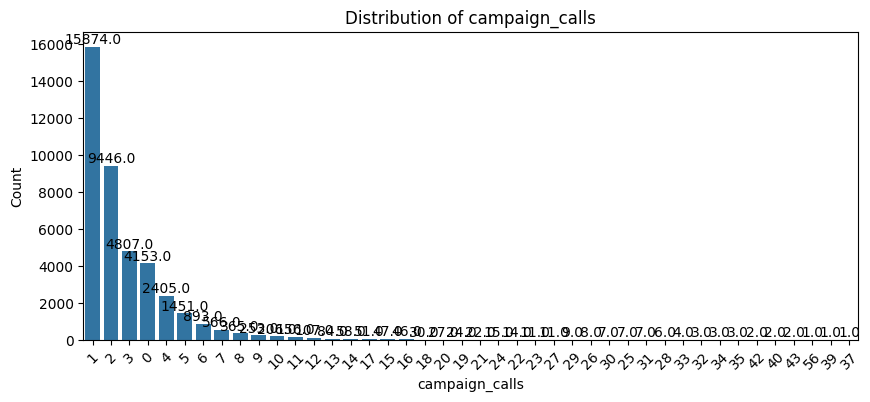

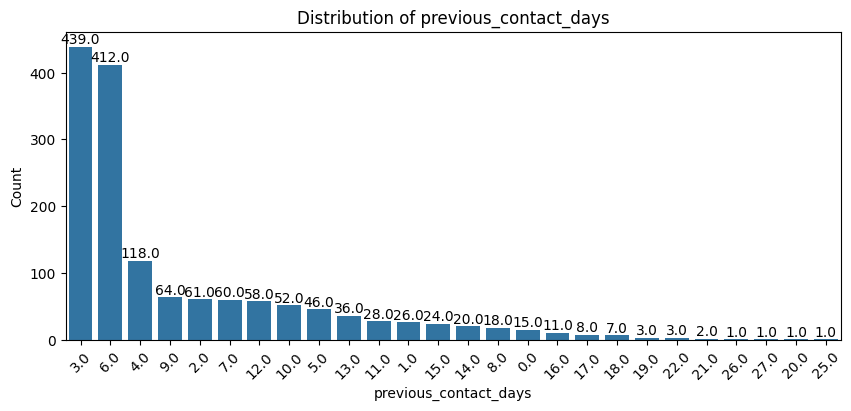

In [49]:
countplot_with_labels("occupation")
countplot_with_labels("marital_status")
countplot_with_labels("education_level")
countplot_with_labels("credit_default")
countplot_with_labels("housing_loan")
countplot_with_labels("personal_loan")
countplot_with_labels("contact_method")
countplot_with_labels("campaign_calls")
countplot_with_labels("previous_contact_days")

## Subscription vs Categorical Features

Here I compare subscription_status against key categorical variables. This helps show
which occupations, age groups, education levels, and loan statuses correlate with higher
or lower subscription rates.

### Subscription vs Categorical Features — Insight

Comparing subscription_status against key categorical variables reveals clear behavioural
patterns. Some occupations, such as students and certain service-related roles, show
higher subscription rates, while others like blue_collar or retired clients subscribe at
lower rates. This suggests that client profession influences interest in the subscription
offer.

Marital status also shows meaningful differences. Single and divorced clients have
slightly higher subscription proportions compared to married clients. This might reflect
differences in financial goals or flexibility across life stages.

Education level appears to have an influence as well. Clients with higher education,
especially university_degree or professional_course, tend to subscribe at higher rates.
This may be linked to greater financial awareness or engagement.

Age_group and loan-related categories show similar patterns — younger, mid-career adults
subscribe more often than older age groups, and clients with certain loan profiles show
different levels of interest.

These patterns confirm that the subscription behaviour is not random. Instead, it varies
across multiple demographic dimensions, which makes these variables helpful predictors for
a future machine learning model.


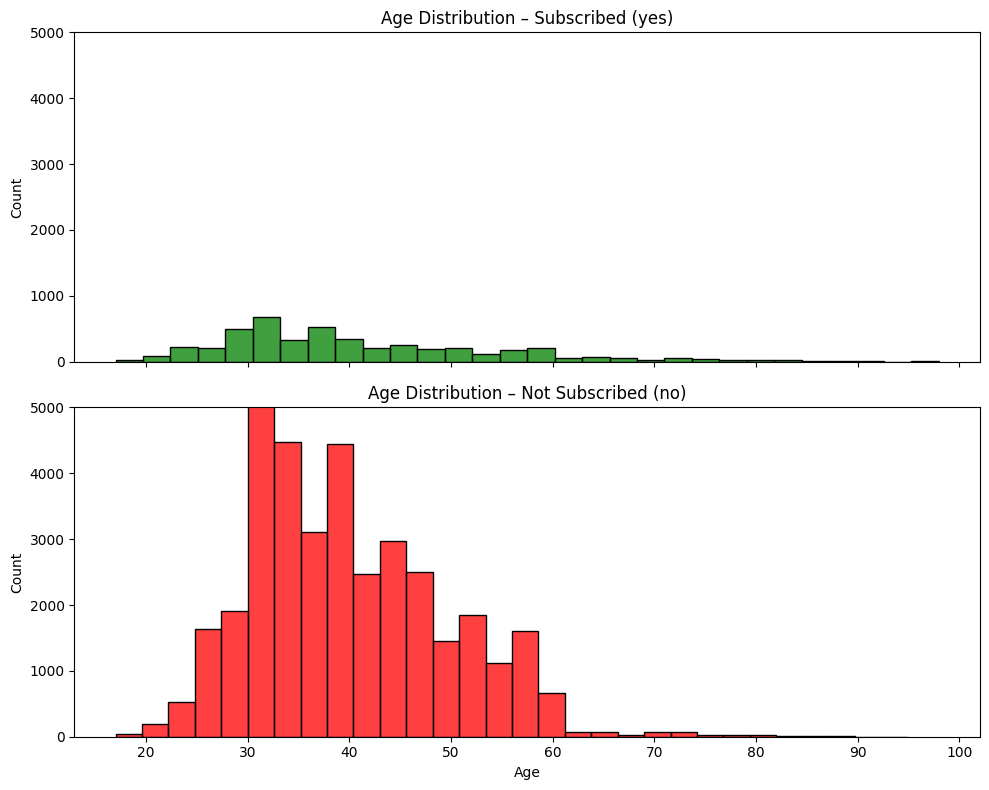

In [50]:
fig, axes = plt.subplots(2, 1, figsize=(10,8), sharex=True)

# YES histogram
sns.histplot(
    df[df["subscription_status"] == "yes"]["age"],
    bins=30,
    color="green",
    ax=axes[0]
)
axes[0].set_title("Age Distribution – Subscribed (yes)")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")
axes[0].set_ylim(0, 5000)     # <-- FIXED Y LIMIT

# NO histogram
sns.histplot(
    df[df["subscription_status"] == "no"]["age"],
    bins=30,
    color="red",
    ax=axes[1]
)
axes[1].set_title("Age Distribution – Not Subscribed (no)")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Count")
axes[1].set_ylim(0, 5000)     # <-- FIXED Y LIMIT

plt.tight_layout()
plt.show()


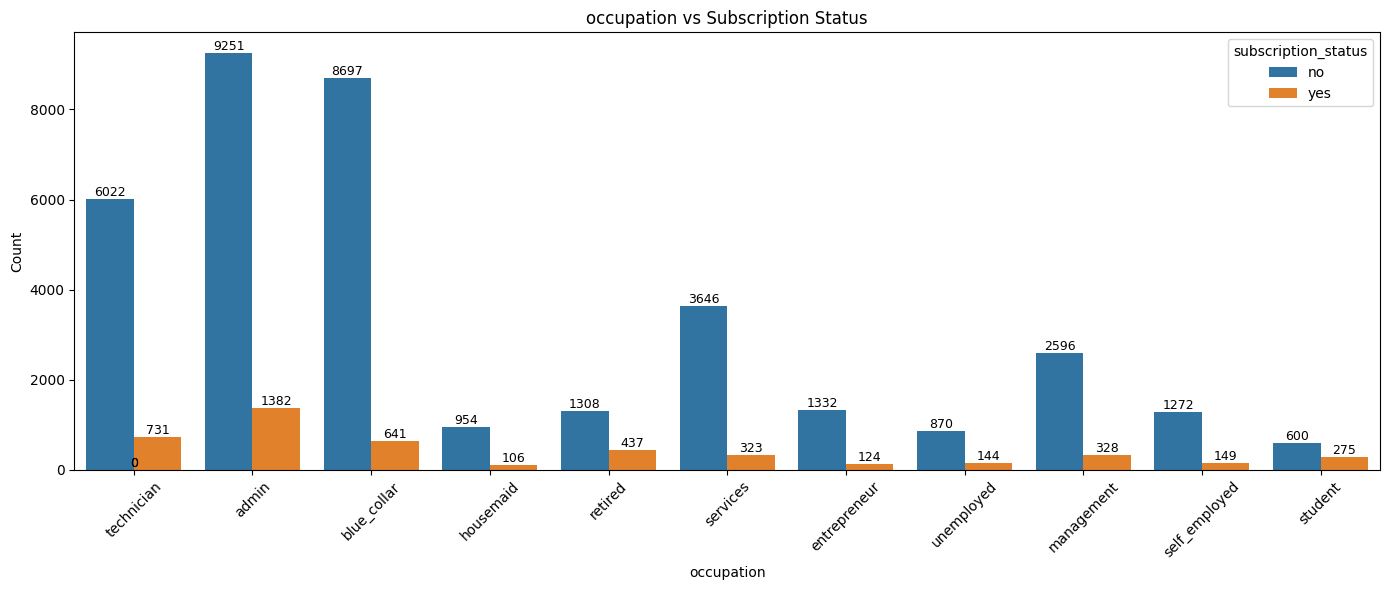

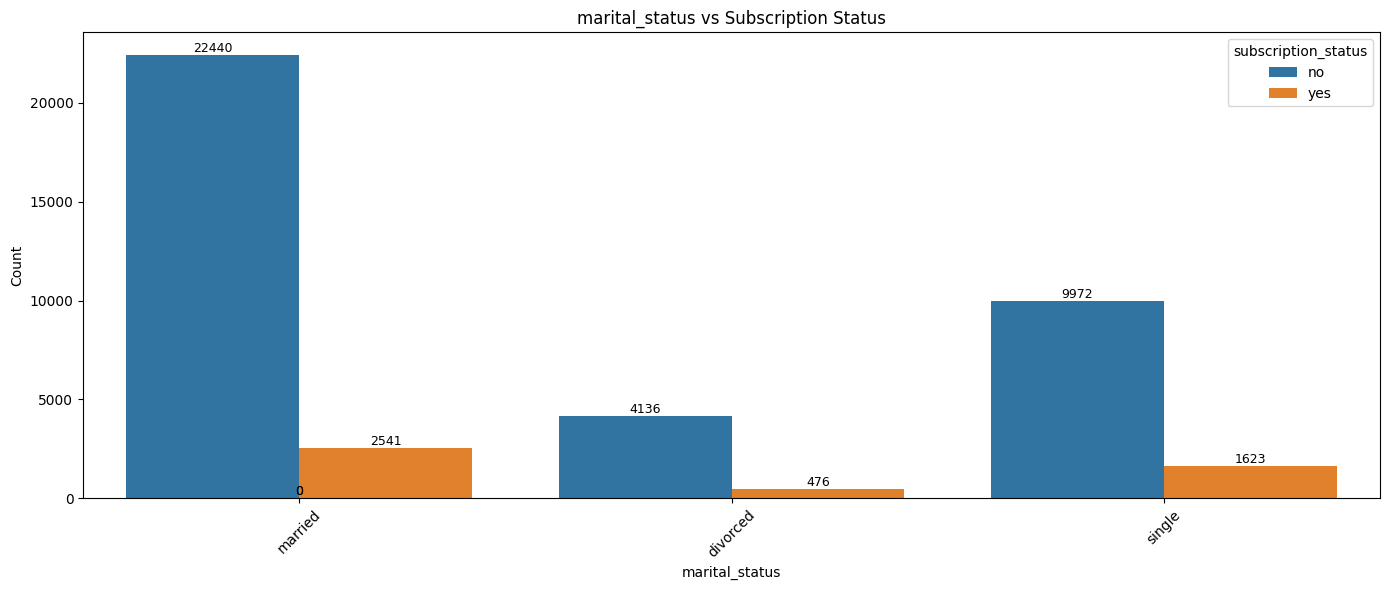

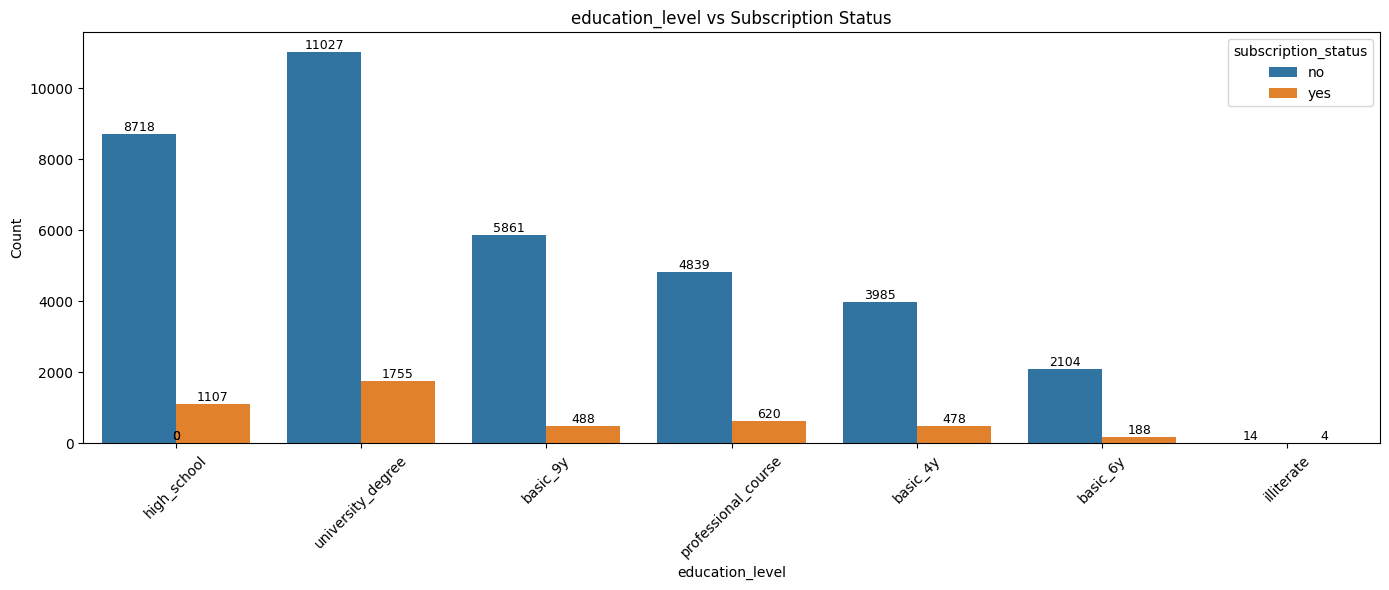

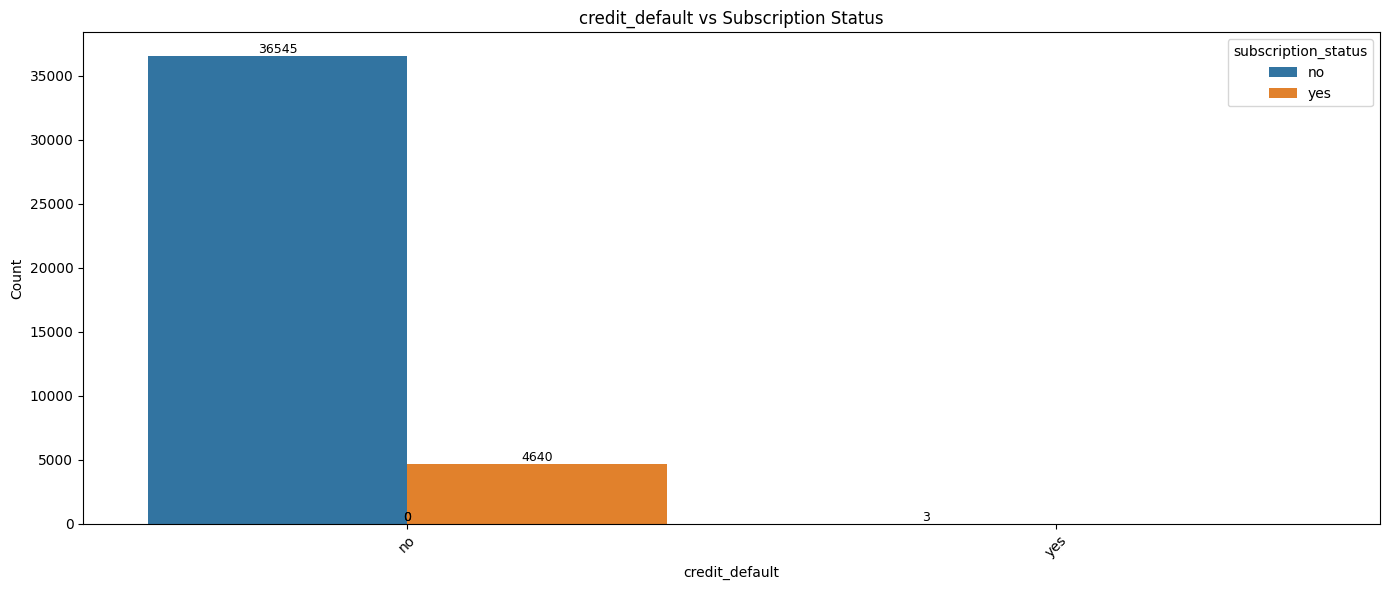

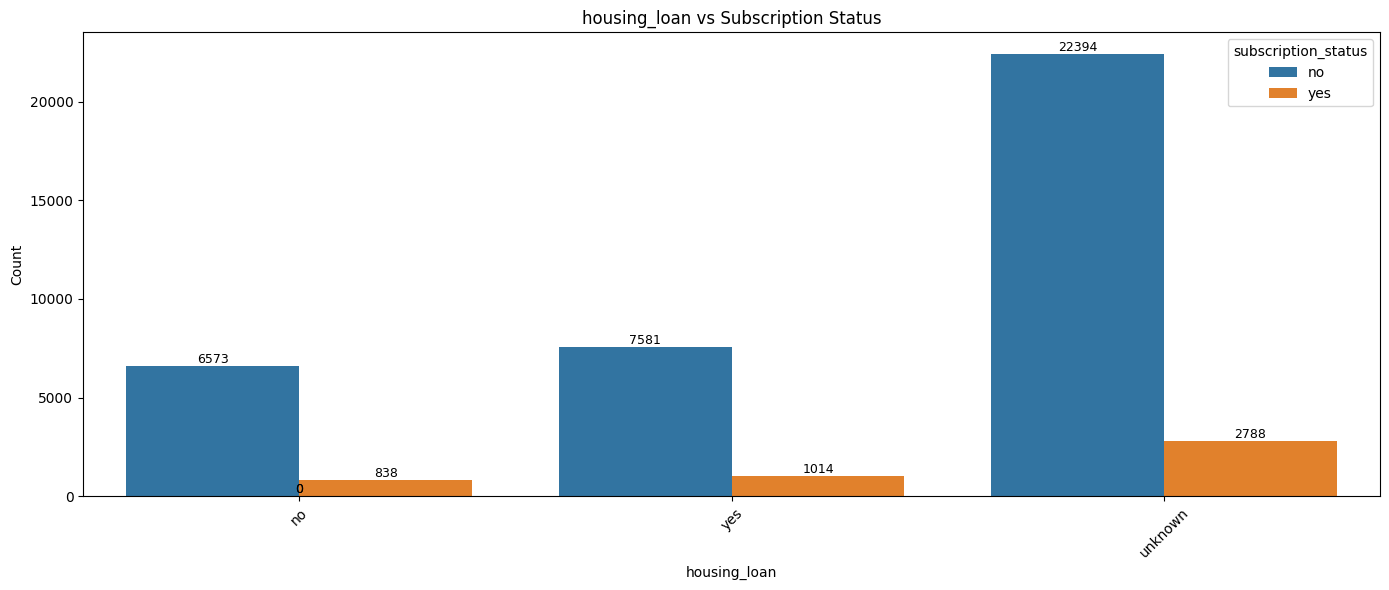

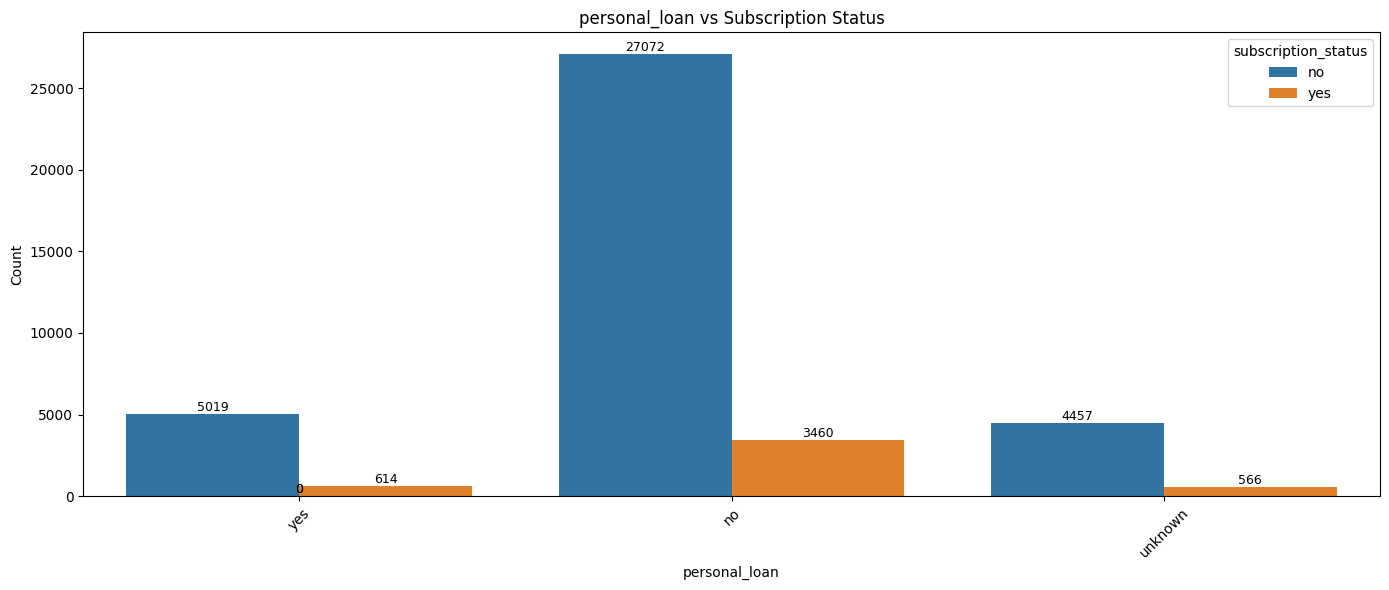

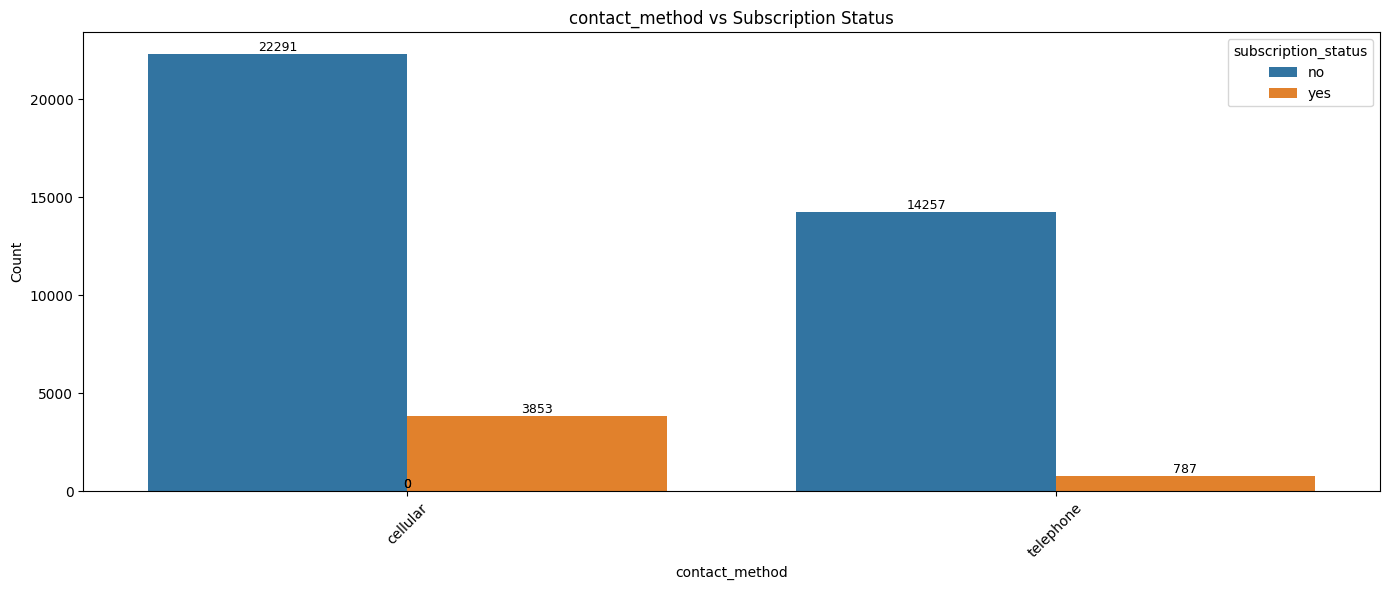

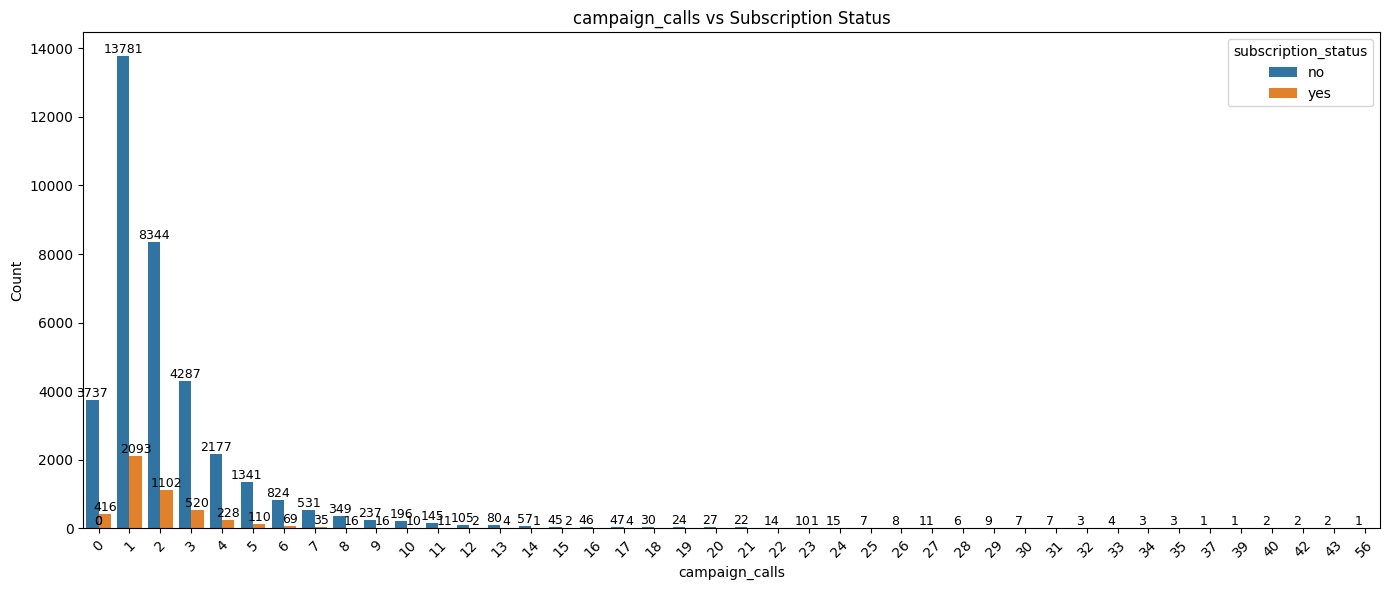

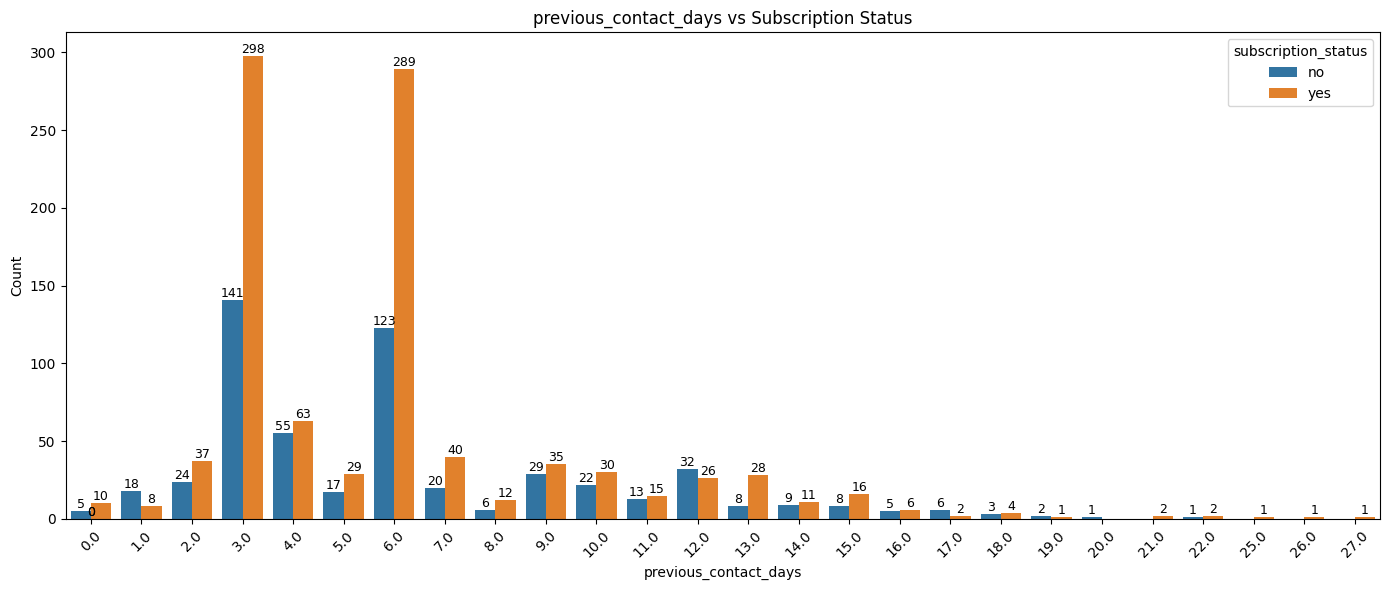

In [51]:
cat_cols = [
    'occupation', 'marital_status', 'education_level', 'credit_default',
    'housing_loan', 'personal_loan', 'contact_method',
    'campaign_calls', 'previous_contact_days'
]

for c in cat_cols:
    plt.figure(figsize=(14,6))   # <-- wider chart

    ax = sns.countplot(data=df, x=c, hue='subscription_status')

    # Rotate labels if too long
    plt.xticks(rotation=45)

    plt.title(f"{c} vs Subscription Status")
    plt.xlabel(c)
    plt.ylabel("Count")

    # ---- ADD LABELS ON TOP OF EACH BAR ----
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(
            f'{int(height)}',
            (p.get_x() + p.get_width()/2., height),
            ha='center', va='bottom',
            fontsize=9
        )
    
    plt.tight_layout()
    plt.show()


## Feature Engineering

I create a modelling dataset (`df_model`) and engineer several new features:

- subscription_flag (binary)
- age_group
- previous_contact_flag
- contact_intensity
- higher_education flag
- loan_burden

These new features help the model capture more meaningful patterns.


In [52]:
# Working copy of cleaned EDA dataframe
df_model = df.copy()


In [53]:
# Binary encode target
df_model["subscription_status_encoded"] = df_model["subscription_status"].map({
    "no": 0,
    "yes": 1
})

In [54]:
df_model["credit_default_enc"] = df_model["credit_default"].map({"no": 0, "yes": 1})

In [55]:
df_model["housing_loan_enc"] = df_model["housing_loan"].map({
    "no": 0, "yes": 1, "unknown": -1
})

In [56]:
df_model["personal_loan_enc"] = df_model["personal_loan"].map({
    "no": 0, "yes": 1, "unknown": -1
})

In [57]:
df_model["age_group"] = pd.cut(
    df_model["age"],
    bins=[16, 25, 35, 50, 65, np.inf],
    labels=["17-25", "26-35", "36-50", "51-65", "65+"]
)

In [58]:
df_model["campaign_calls"] = pd.to_numeric(df_model["campaign_calls"], errors="coerce")
df_model["previous_contact_days"] = pd.to_numeric(df_model["previous_contact_days"], errors="coerce")

df_model["previous_contact_flag"] = df_model["previous_contact_days"].notna().astype(int)

df_model["contact_intensity"] = df_model["campaign_calls"] / (df_model["previous_contact_days"].fillna(0) + 1)


In [59]:
df_model["education_level"] = (
    df_model["education_level"]
    .astype(str).str.lower().str.strip()
)

higher_edu = {
    "university_degree", "university", "tertiary",
    "professional_course", "professional"
}

df_model["is_higher_edu"] = df_model["education_level"].isin(higher_edu).astype(int)

loan_yes_df = pd.DataFrame({
    "housing": (df_model["housing_loan"] == "yes").astype(int),
    "personal": (df_model["personal_loan"] == "yes").astype(int),
    "default": (df_model["credit_default"] == "yes").astype(int),
})
df_model["loan_burden"] = loan_yes_df.sum(axis=1)


## One-Hot Encoding

All categorical features are converted to dummy variables so the dataset becomes fully
numeric. I then drop the original string columns to avoid duplication.


In [60]:
cat_cols = [
    "occupation", "marital_status", "education_level",
    "contact_method", "age_group"
]

for c in cat_cols:
    df_model[c] = df_model[c].astype(str).str.lower().str.strip()

df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)


In [61]:
drop_cols = [
    "client_id",
    "previous_contact_days",
    "subscription_status",
    "credit_default",
    "housing_loan",
    "personal_loan",
    "occupation_impute_stage",
    "marital_impute_stage",
    "education_impute_stage"
]

df_model = df_model.drop(columns=drop_cols, errors="ignore")

X = df_model.drop(columns=["subscription_status_encoded"])
y = df_model["subscription_status_encoded"]


In [62]:
numeric_df = df_model.select_dtypes(include=['int64', 'float64'])
numeric_df.head()


,age,campaign_calls,subscription_status_encoded,credit_default_enc,housing_loan_enc,personal_loan_enc,previous_contact_flag,contact_intensity,is_higher_edu,loan_burden
0,57,1,0,0,0,1,0,1.0,0,1
1,55,2,0,0,1,0,0,2.0,1,1
2,33,1,0,0,0,0,0,1.0,0,0
3,36,4,0,0,0,0,0,4.0,0,0
4,27,2,0,0,-1,0,0,2.0,0,0


## Correlation Heatmap

I compute a correlation matrix and visualise it using a heatmap. This helps identify
strong relationships between features and highlights any redundancy among engineered
variables.


In [63]:
corr = numeric_df.corr()


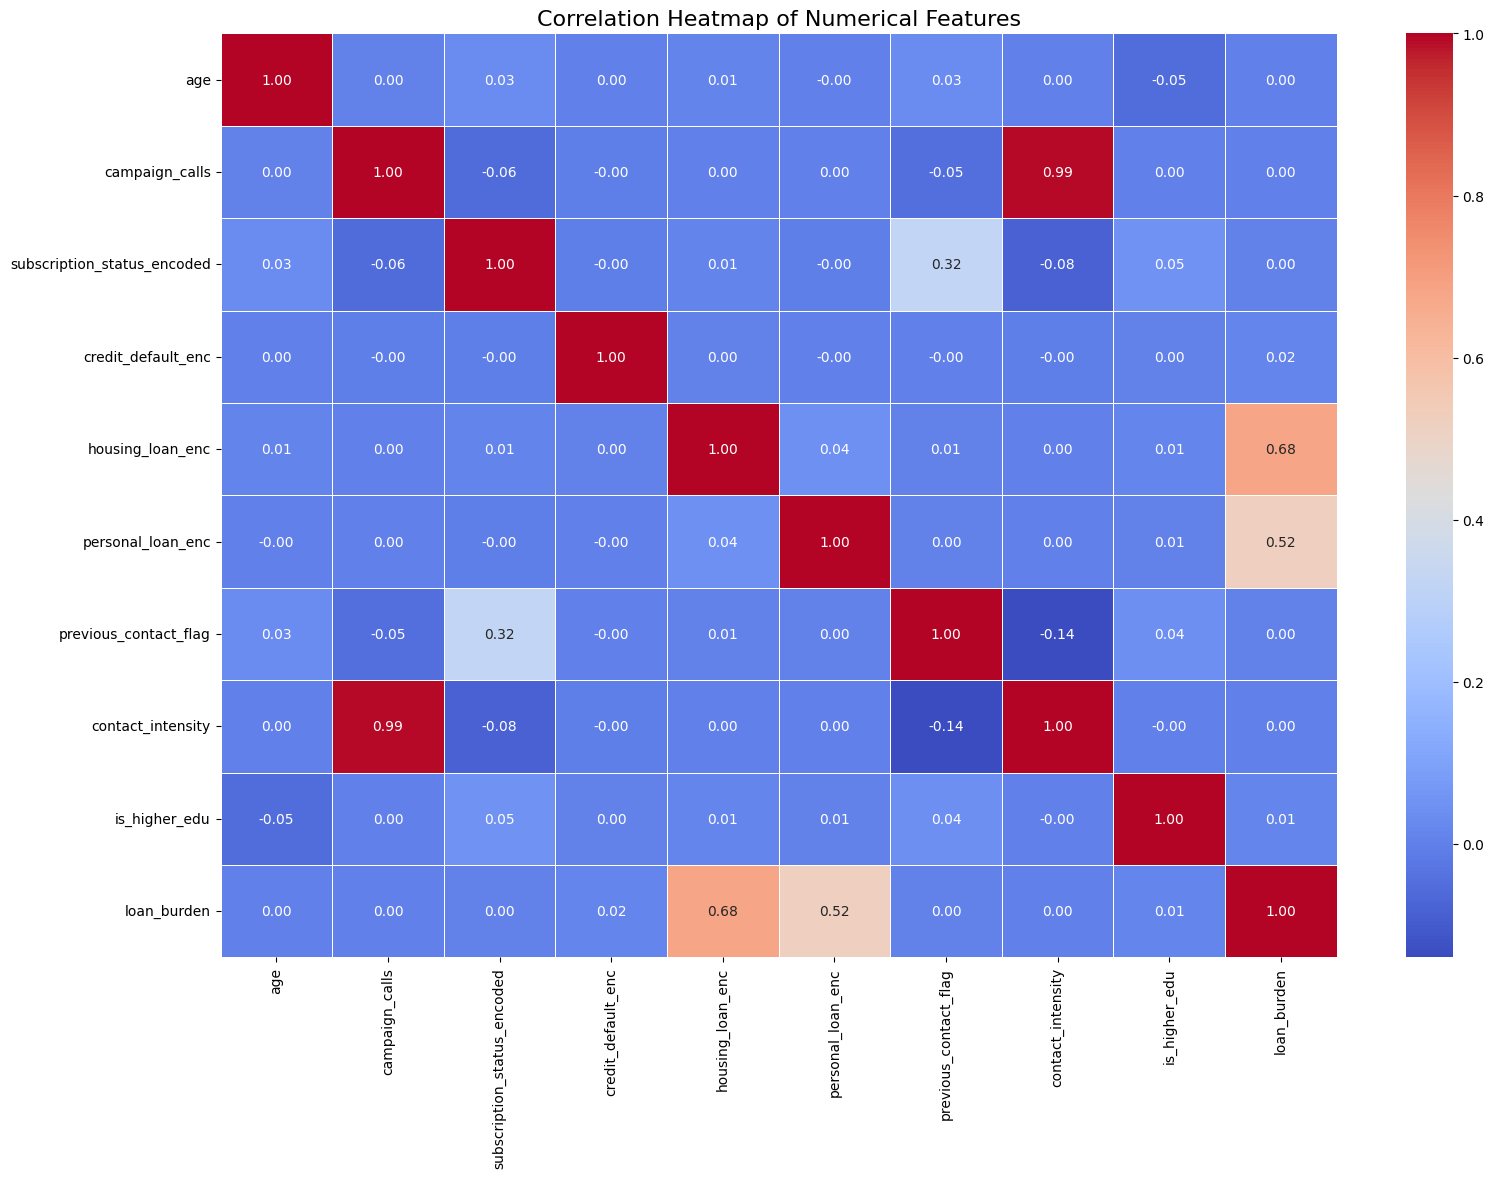

In [64]:
plt.figure(figsize=(18, 12))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=False
)
plt.title("Correlation Heatmap of Numerical Features", fontsize=16)
plt.show()


## Saving the Final Dataset

Lastly, I save the cleaned and fully processed dataset into a new database
(`final_bmarket.db`). This makes it easy to use the final data directly for modelling.


In [65]:
df_model

,age,campaign_calls,subscription_status_encoded,credit_default_enc,housing_loan_enc,personal_loan_enc,previous_contact_flag,contact_intensity,is_higher_edu,loan_burden,occupation_blue_collar,occupation_entrepreneur,occupation_housemaid,occupation_management,occupation_retired,occupation_self_employed,occupation_services,occupation_student,occupation_technician,occupation_unemployed,marital_status_married,marital_status_single,education_level_basic_6y,education_level_basic_9y,education_level_high_school,education_level_illiterate,education_level_professional_course,education_level_university_degree,contact_method_telephone,age_group_26-35,age_group_36-50,age_group_51-65,age_group_65+
0,57,1,0,0,0,1,0,1.0,0,1,False,False,False,False,False,False,False,False,True,False,True,False,False,False,True,False,False,False,False,False,False,True,False
1,55,2,0,0,1,0,0,2.0,1,1,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,True,False,False,True,False
2,33,1,0,0,0,0,0,1.0,0,0,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False
3,36,4,0,0,0,0,0,4.0,0,0,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False,True,False,False
4,27,2,0,0,-1,0,0,2.0,0,0,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,58,2,0,0,0,0,0,2.0,1,0,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False,True,False
41184,37,1,0,0,0,0,0,1.0,1,0,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,True,True,False,True,False,False
41185,35,1,1,0,-1,0,1,0.2,0,0,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False
41186,40,2,0,0,-1,0,0,2.0,1,0,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,True,True,False,True,False,False


In [67]:
# Create a NEW database file named "final_model_dataset.db"
conn = sqlite3.connect("final_bmarket.db")

# Save df_model inside it as a table
df_model.to_sql("df_model_table", conn, if_exists="replace", index=False)

# Close the connection
conn.close()

print("df_model successfully saved to final_model_dataset.db")


df_model successfully saved to final_model_dataset.db
